# Supervised Writer Classification Baseline

This notebook establishes the first supervised baseline for the QUWI dataset.

## Purpose

- Validate the reusable Dataset and DataLoader modules
- Train a compact writer-classification model on development writers
- Monitor training and validation loss
- Measure closed-set writer-identification accuracy
- Examine whether the model learns writer-discriminative features
- Create a baseline checkpoint for later verification experiments

This classification experiment is an intermediate diagnostic baseline. The final research task will evaluate writer verification under cross-script, open-set, and content-controlled protocols.

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.optim import AdamW
from torchvision.models import resnet18

In [2]:
from torch.utils.data import DataLoader

from handwriting_cross_script_research import QUWIDataset

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

PROJECT_ROOT = Path.cwd().resolve()

while PROJECT_ROOT != PROJECT_ROOT.parent and not (
    PROJECT_ROOT / "pyproject.toml"
).exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

assert (PROJECT_ROOT / "pyproject.toml").exists()

IMAGE_DIR = (
    Path.home()
    / "Documents"
    / "Handwriting"
    / "QUWI"
    / "extracted"
    / "images"
)

SPLIT_PATH = (
    PROJECT_ROOT
    / "splits"
    / "quwi_writer_disjoint_split_seed42.csv"
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Project root:", PROJECT_ROOT)
print("Image directory exists:", IMAGE_DIR.exists())
print("Split file exists:", SPLIT_PATH.exists())
print("Random seed:", SEED)
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Project root: /home/arijit/Documents/handwriting-cross-script-research
Image directory exists: True
Split file exists: True
Random seed: 42
Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
split_df = pd.read_csv(SPLIT_PATH)

development_df = split_df[
    split_df["experiment_split"] == "development_train"
].copy()

condition_summary = (
    development_df
    .groupby(
        ["page_id", "language", "same_text"],
        as_index=False,
    )
    .agg(
        images=("filename", "size"),
        writers=("writer", "nunique"),
    )
)

print("Development images:", len(development_df))
print("Development writers:", development_df["writer"].nunique())
print(
    "Images per writer:",
    sorted(development_df.groupby("writer").size().unique().tolist()),
)

display(condition_summary)

assert len(development_df) == 904
assert development_df["writer"].nunique() == 226
assert development_df.groupby("writer").size().eq(4).all()

Development images: 904
Development writers: 226
Images per writer: [4]


,page_id,language,same_text,images,writers
0,1,Arabic,0,226,226
1,2,Arabic,1,226,226
2,3,English,0,226,226
3,4,English,1,226,226


In [4]:
arabic_train_df = development_df[
    development_df["page_id"].isin([1, 2])
].copy()

english_variable_validation_df = development_df[
    development_df["page_id"] == 3
].copy()

english_same_test_df = development_df[
    development_df["page_id"] == 4
].copy()

development_writers = sorted(
    development_df["writer"].unique().tolist()
)

writer_to_class = {
    writer_id: class_index
    for class_index, writer_id in enumerate(development_writers)
}

class_to_writer = {
    class_index: writer_id
    for writer_id, class_index in writer_to_class.items()
}

for dataframe in [
    arabic_train_df,
    english_variable_validation_df,
    english_same_test_df,
]:
    dataframe["writer_label"] = dataframe["writer"].map(writer_to_class)

writer_label_lookup = torch.full(
    (max(development_writers) + 1,),
    -1,
    dtype=torch.long,
)

for writer_id, class_index in writer_to_class.items():
    writer_label_lookup[writer_id] = class_index

train_writers = set(arabic_train_df["writer"])
validation_writers = set(english_variable_validation_df["writer"])
test_writers = set(english_same_test_df["writer"])

print(
    "Arabic train:",
    len(arabic_train_df),
    "images,",
    arabic_train_df["writer"].nunique(),
    "writers, pages",
    sorted(arabic_train_df["page_id"].unique().tolist()),
)

print(
    "English variable validation:",
    len(english_variable_validation_df),
    "images,",
    english_variable_validation_df["writer"].nunique(),
    "writers, pages",
    sorted(english_variable_validation_df["page_id"].unique().tolist()),
)

print(
    "English same-text test:",
    len(english_same_test_df),
    "images,",
    english_same_test_df["writer"].nunique(),
    "writers, pages",
    sorted(english_same_test_df["page_id"].unique().tolist()),
)

print("Writer classes:", len(writer_to_class))
print(
    "Original writer-ID range:",
    min(development_writers),
    "to",
    max(development_writers),
)
print(
    "Class-label range:",
    min(writer_to_class.values()),
    "to",
    max(writer_to_class.values()),
)
print(
    "Same writer set across conditions:",
    train_writers == validation_writers == test_writers,
)

assert len(arabic_train_df) == 452
assert len(english_variable_validation_df) == 226
assert len(english_same_test_df) == 226
assert len(writer_to_class) == 226
assert set(writer_to_class.values()) == set(range(226))
assert train_writers == validation_writers == test_writers

Arabic train: 452 images, 226 writers, pages [1, 2]
English variable validation: 226 images, 226 writers, pages [3]
English same-text test: 226 images, 226 writers, pages [4]
Writer classes: 226
Original writer-ID range: 1 to 282
Class-label range: 0 to 225
Same writer set across conditions: True


In [5]:
BATCH_SIZE = 8
NUM_WORKERS = 0

arabic_train_dataset = QUWIDataset(
    metadata=arabic_train_df,
    image_dir=IMAGE_DIR,
)

english_variable_validation_dataset = QUWIDataset(
    metadata=english_variable_validation_df,
    image_dir=IMAGE_DIR,
)

english_same_test_dataset = QUWIDataset(
    metadata=english_same_test_df,
    image_dir=IMAGE_DIR,
)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    arabic_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)

validation_loader = DataLoader(
    english_variable_validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    english_same_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

train_batch = next(iter(train_loader))
train_class_labels = writer_label_lookup[
    train_batch["writer_id"]
]

print(
    "Dataset sizes:",
    {
        "arabic_train": len(arabic_train_dataset),
        "english_variable_validation": len(
            english_variable_validation_dataset
        ),
        "english_same_test": len(english_same_test_dataset),
    },
)

print(
    "Loader batches:",
    {
        "train": len(train_loader),
        "validation": len(validation_loader),
        "test": len(test_loader),
    },
)

print("Train image shape:", train_batch["image"].shape)
print("Train filenames:", train_batch["filename"])
print("Original writer IDs:", train_batch["writer_id"].tolist())
print("Contiguous class labels:", train_class_labels.tolist())
print("Pin memory:", train_loader.pin_memory)

assert train_batch["image"].shape == (8, 3, 384, 384)
assert train_class_labels.min().item() >= 0
assert train_class_labels.max().item() < 226

Dataset sizes: {'arabic_train': 452, 'english_variable_validation': 226, 'english_same_test': 226}
Loader batches: {'train': 57, 'validation': 29, 'test': 29}
Train image shape: torch.Size([8, 3, 384, 384])
Train filenames: ['0157_1.jpg', '0243_1.jpg', '0086_1.jpg', '0178_1.jpg', '0002_1.jpg', '0227_1.jpg', '0019_1.jpg', '0221_1.jpg']
Original writer IDs: [157, 243, 86, 178, 2, 227, 19, 221]
Contiguous class labels: [118, 189, 64, 136, 1, 176, 13, 170]
Pin memory: True


In [6]:
from torchvision.models import ResNet18_Weights

NUM_CLASSES = len(writer_to_class)

IMAGENET_MEAN = (
    0.485,
    0.456,
    0.406,
)

IMAGENET_STD = (
    0.229,
    0.224,
    0.225,
)


class WriterClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        weights = ResNet18_Weights.DEFAULT
        backbone = resnet18(weights=weights)
        feature_dimension = backbone.fc.in_features
        backbone.fc = nn.Identity()

        for parameter in backbone.parameters():
            parameter.requires_grad = False

        self.feature_extractor = backbone
        self.classifier = nn.Linear(
            feature_dimension,
            num_classes,
        )

        self.register_buffer(
            "normalization_mean",
            torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1),
        )

        self.register_buffer(
            "normalization_std",
            torch.tensor(IMAGENET_STD).view(1, 3, 1, 1),
        )

    def forward(self, images):
        images = (
            images - self.normalization_mean
        ) / self.normalization_std

        with torch.no_grad():
            features = self.feature_extractor(images)

        logits = self.classifier(features)

        return logits

    def train(self, mode=True):
        super().train(mode)
        self.feature_extractor.eval()
        return self


model = WriterClassifier(
    num_classes=NUM_CLASSES,
).to(DEVICE)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

frozen_parameters = (
    total_parameters - trainable_parameters
)

print("Model:", model.feature_extractor.__class__.__name__)
print("Writer classes:", NUM_CLASSES)
print("Total parameters:", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")
print("Frozen parameters:", f"{frozen_parameters:,}")
print(
    "Classifier output features:",
    model.classifier.out_features,
)
print(
    "Model device:",
    next(model.parameters()).device,
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/arijit/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


Model: ResNet
Writer classes: 226
Total parameters: 11,292,450
Trainable parameters: 115,938
Frozen parameters: 11,176,512
Classifier output features: 226
Model device: cuda:0


In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

model.train()
optimizer.zero_grad(set_to_none=True)

batch_images = train_batch["image"].to(
    DEVICE,
    non_blocking=True,
)

batch_labels = writer_label_lookup[
    train_batch["writer_id"]
].to(
    DEVICE,
    non_blocking=True,
)

batch_logits = model(batch_images)
batch_loss = criterion(
    batch_logits,
    batch_labels,
)

batch_loss.backward()

classifier_gradient_norm = (
    model.classifier.weight.grad.norm().item()
)

batch_predictions = batch_logits.argmax(dim=1)
batch_correct = (
    batch_predictions == batch_labels
).sum().item()

print("Input shape:", batch_images.shape)
print("Logit shape:", batch_logits.shape)
print("Target shape:", batch_labels.shape)
print("Target range:", batch_labels.min().item(), "to", batch_labels.max().item())
print("Initial loss:", round(batch_loss.item(), 6))
print("Correct predictions:", batch_correct, "of", len(batch_labels))
print("Classifier gradient norm:", round(classifier_gradient_norm, 6))
print("Finite logits:", torch.isfinite(batch_logits).all().item())
print("Finite loss:", torch.isfinite(batch_loss).item())
print(
    "Finite classifier gradients:",
    torch.isfinite(
        model.classifier.weight.grad
    ).all().item(),
)

optimizer.zero_grad(set_to_none=True)

assert batch_logits.shape == (8, 226)
assert torch.isfinite(batch_logits).all()
assert torch.isfinite(batch_loss)
assert torch.isfinite(
    model.classifier.weight.grad
) if model.classifier.weight.grad is not None else True

Input shape: torch.Size([8, 3, 384, 384])
Logit shape: torch.Size([8, 226])
Target shape: torch.Size([8])
Target range: 1 to 189
Initial loss: 5.337851
Correct predictions: 0 of 8
Classifier gradient norm: 4.414146
Finite logits: True
Finite loss: True
Finite classifier gradients: True


In [8]:
def get_writer_labels(batch, label_lookup, device):
    labels = label_lookup[
        batch["writer_id"]
    ]

    return labels.to(
        device,
        non_blocking=True,
    )


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    label_lookup,
    device,
):
    model.train()

    total_loss = 0.0
    total_samples = 0
    top1_correct = 0
    top5_correct = 0

    for batch in loader:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        labels = get_writer_labels(
            batch,
            label_lookup,
            device,
        )

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.shape[0]
        top5_predictions = logits.topk(
            k=5,
            dim=1,
        ).indices

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        top1_correct += (
            top5_predictions[:, 0] == labels
        ).sum().item()

        top5_correct += (
            top5_predictions == labels.unsqueeze(1)
        ).any(dim=1).sum().item()

    return {
        "loss": total_loss / total_samples,
        "top1_accuracy": top1_correct / total_samples,
        "top5_accuracy": top5_correct / total_samples,
        "samples": total_samples,
    }


@torch.inference_mode()
def evaluate_model(
    model,
    loader,
    criterion,
    label_lookup,
    device,
):
    model.eval()

    total_loss = 0.0
    total_samples = 0
    top1_correct = 0
    top5_correct = 0

    for batch in loader:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        labels = get_writer_labels(
            batch,
            label_lookup,
            device,
        )

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = images.shape[0]
        top5_predictions = logits.topk(
            k=5,
            dim=1,
        ).indices

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        top1_correct += (
            top5_predictions[:, 0] == labels
        ).sum().item()

        top5_correct += (
            top5_predictions == labels.unsqueeze(1)
        ).any(dim=1).sum().item()

    return {
        "loss": total_loss / total_samples,
        "top1_accuracy": top1_correct / total_samples,
        "top5_accuracy": top5_correct / total_samples,
        "samples": total_samples,
    }

In [9]:
train_evaluation_loader = DataLoader(
    arabic_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

initial_metrics = {
    "arabic_train": evaluate_model(
        model,
        train_evaluation_loader,
        criterion,
        writer_label_lookup,
        DEVICE,
    ),
    "english_variable_validation": evaluate_model(
        model,
        validation_loader,
        criterion,
        writer_label_lookup,
        DEVICE,
    ),
    "english_same_test": evaluate_model(
        model,
        test_loader,
        criterion,
        writer_label_lookup,
        DEVICE,
    ),
}

initial_metrics_df = (
    pd.DataFrame(initial_metrics)
    .T
    .reset_index()
    .rename(columns={"index": "condition"})
)

initial_metrics_df[
    "top1_accuracy_percent"
] = (
    initial_metrics_df["top1_accuracy"] * 100
)

initial_metrics_df[
    "top5_accuracy_percent"
] = (
    initial_metrics_df["top5_accuracy"] * 100
)

display(
    initial_metrics_df[
        [
            "condition",
            "samples",
            "loss",
            "top1_accuracy_percent",
            "top5_accuracy_percent",
        ]
    ].round(4)
)

print(
    "Random top-1 chance:",
    round(100 / NUM_CLASSES, 4),
    "%",
)

print(
    "Random top-5 chance:",
    round(500 / NUM_CLASSES, 4),
    "%",
)

assert all(
    metrics["samples"] > 0
    for metrics in initial_metrics.values()
)

assert all(
    np.isfinite(metrics["loss"])
    for metrics in initial_metrics.values()
)

,condition,samples,loss,top1_accuracy_percent,top5_accuracy_percent
0,arabic_train,452.0,5.4723,0.6637,1.9912
1,english_variable_validation,226.0,5.4698,0.4425,1.7699
2,english_same_test,226.0,5.4750,0.8850,1.7699


Random top-1 chance: 0.4425 %
Random top-5 chance: 2.2124 %


In [10]:
EPOCHS = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "supervised_baseline"
REPORT_DIR = PROJECT_ROOT / "reports" / "supervised_baseline"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

training_generator = torch.Generator()
training_generator.manual_seed(SEED)

train_loader = DataLoader(
    arabic_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=training_generator,
)

optimizer = AdamW(
    model.classifier.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

history = []
best_epoch = 0
best_validation_top1 = -1.0
best_validation_loss = float("inf")

best_checkpoint_path = (
    CHECKPOINT_DIR
    / "resnet18_linear_probe_best.pt"
)

print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Checkpoint path:", best_checkpoint_path)

Epochs: 15
Learning rate: 0.001
Weight decay: 0.0001
Training batches: 57
Validation batches: 29
Checkpoint path: /home/arijit/Documents/handwriting-cross-script-research/checkpoints/supervised_baseline/resnet18_linear_probe_best.pt


In [11]:
for epoch in range(1, EPOCHS + 1):
    train_metrics = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        writer_label_lookup,
        DEVICE,
    )

    validation_metrics = evaluate_model(
        model,
        validation_loader,
        criterion,
        writer_label_lookup,
        DEVICE,
    )

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_top1_accuracy": train_metrics["top1_accuracy"],
        "train_top5_accuracy": train_metrics["top5_accuracy"],
        "validation_loss": validation_metrics["loss"],
        "validation_top1_accuracy": validation_metrics["top1_accuracy"],
        "validation_top5_accuracy": validation_metrics["top5_accuracy"],
    }

    history.append(epoch_record)

    validation_top1 = validation_metrics["top1_accuracy"]
    validation_loss = validation_metrics["loss"]

    improved = (
        validation_top1 > best_validation_top1
        or (
            validation_top1 == best_validation_top1
            and validation_loss < best_validation_loss
        )
    )

    if improved:
        best_epoch = epoch
        best_validation_top1 = validation_top1
        best_validation_loss = validation_loss

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "writer_to_class": writer_to_class,
                "class_to_writer": class_to_writer,
                "num_classes": NUM_CLASSES,
                "target_size": [384, 384],
                "training_script": "Arabic",
                "validation_script": "English",
                "validation_text_condition": "variable",
                "validation_metrics": validation_metrics,
            },
            best_checkpoint_path,
        )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {train_metrics['loss']:.4f} | "
        f"train top-1 {train_metrics['top1_accuracy'] * 100:.2f}% | "
        f"train top-5 {train_metrics['top5_accuracy'] * 100:.2f}% | "
        f"val loss {validation_metrics['loss']:.4f} | "
        f"val top-1 {validation_metrics['top1_accuracy'] * 100:.2f}% | "
        f"val top-5 {validation_metrics['top5_accuracy'] * 100:.2f}%"
    )

print("\nBest epoch:", best_epoch)
print(
    "Best validation top-1:",
    round(best_validation_top1 * 100, 4),
    "%",
)
print(
    "Best validation loss:",
    round(best_validation_loss, 6),
)
print("Checkpoint exists:", best_checkpoint_path.exists())

Epoch 01/15 | train loss 6.4386 | train top-1 0.00% | train top-5 0.22% | val loss 5.4983 | val top-1 1.77% | val top-5 4.42%
Epoch 02/15 | train loss 5.5639 | train top-1 0.88% | train top-5 1.55% | val loss 5.3661 | val top-1 1.77% | val top-5 6.19%
Epoch 03/15 | train loss 5.3687 | train top-1 1.77% | train top-5 4.65% | val loss 5.3256 | val top-1 1.77% | val top-5 5.31%
Epoch 04/15 | train loss 5.2025 | train top-1 3.98% | train top-5 11.06% | val loss 5.2955 | val top-1 2.65% | val top-5 7.52%
Epoch 05/15 | train loss 5.0478 | train top-1 6.19% | train top-5 17.26% | val loss 5.2605 | val top-1 3.54% | val top-5 8.41%
Epoch 06/15 | train loss 4.9054 | train top-1 8.63% | train top-5 22.35% | val loss 5.2336 | val top-1 2.65% | val top-5 7.96%
Epoch 07/15 | train loss 4.7726 | train top-1 9.73% | train top-5 25.88% | val loss 5.2190 | val top-1 3.10% | val top-5 8.85%
Epoch 08/15 | train loss 4.6449 | train top-1 12.83% | train top-5 33.19% | val loss 5.1996 | val top-1 2.65% | va

In [12]:
checkpoint = torch.load(
    best_checkpoint_path,
    map_location=DEVICE,
    weights_only=False,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_epoch = checkpoint["epoch"]

best_model_metrics = {
    "arabic_train": evaluate_model(
        model,
        train_evaluation_loader,
        criterion,
        writer_label_lookup,
        DEVICE,
    ),
    "english_variable_validation": evaluate_model(
        model,
        validation_loader,
        criterion,
        writer_label_lookup,
        DEVICE,
    ),
    "english_same_test": evaluate_model(
        model,
        test_loader,
        criterion,
        writer_label_lookup,
        DEVICE,
    ),
}

print("Loaded checkpoint epoch:", best_epoch)
print(
    "Stored validation top-1:",
    round(
        checkpoint["validation_metrics"]["top1_accuracy"] * 100,
        4,
    ),
    "%",
)
print(
    "Stored validation loss:",
    round(
        checkpoint["validation_metrics"]["loss"],
        6,
    ),
)

Loaded checkpoint epoch: 14
Stored validation top-1: 4.4248 %
Stored validation loss: 5.117608


In [13]:
best_model_metrics_df = (
    pd.DataFrame(best_model_metrics)
    .T
    .reset_index()
    .rename(columns={"index": "condition"})
)

best_model_metrics_df["top1_accuracy_percent"] = (
    best_model_metrics_df["top1_accuracy"] * 100
)

best_model_metrics_df["top5_accuracy_percent"] = (
    best_model_metrics_df["top5_accuracy"] * 100
)

display(
    best_model_metrics_df[
        [
            "condition",
            "samples",
            "loss",
            "top1_accuracy_percent",
            "top5_accuracy_percent",
        ]
    ].round(4)
)

train_top1 = best_model_metrics[
    "arabic_train"
]["top1_accuracy"]

validation_top1 = best_model_metrics[
    "english_variable_validation"
]["top1_accuracy"]

test_top1 = best_model_metrics[
    "english_same_test"
]["top1_accuracy"]

print(
    "Random top-1 chance:",
    round(100 / NUM_CLASSES, 4),
    "%",
)

print(
    "Train-validation top-1 gap:",
    round(
        (train_top1 - validation_top1) * 100,
        4,
    ),
    "percentage points",
)

print(
    "Validation-test top-1 difference:",
    round(
        (test_top1 - validation_top1) * 100,
        4,
    ),
    "percentage points",
)

print(
    "Test improvement over random chance:",
    round(
        test_top1 * NUM_CLASSES,
        4,
    ),
    "times",
)

,condition,samples,loss,top1_accuracy_percent,top5_accuracy_percent
0,arabic_train,452.0,3.5954,66.8142,88.9381
1,english_variable_validation,226.0,5.1176,4.4248,11.9469
2,english_same_test,226.0,5.1425,3.5398,14.1593


Random top-1 chance: 0.4425 %
Train-validation top-1 gap: 62.3894 percentage points
Validation-test top-1 difference: -0.885 percentage points
Test improvement over random chance: 8.0 times


In [14]:
history_df = pd.DataFrame(history)

history_df["train_top1_percent"] = (
    history_df["train_top1_accuracy"] * 100
)

history_df["train_top5_percent"] = (
    history_df["train_top5_accuracy"] * 100
)

history_df["validation_top1_percent"] = (
    history_df["validation_top1_accuracy"] * 100
)

history_df["validation_top5_percent"] = (
    history_df["validation_top5_accuracy"] * 100
)

display(
    history_df[
        [
            "epoch",
            "train_loss",
            "train_top1_percent",
            "train_top5_percent",
            "validation_loss",
            "validation_top1_percent",
            "validation_top5_percent",
        ]
    ].round(4)
)

best_history_row = history_df[
    history_df["epoch"] == best_epoch
].iloc[0]

print("Recorded epochs:", len(history_df))
print("Best epoch:", best_epoch)
print(
    "Best-row validation top-1:",
    round(
        best_history_row["validation_top1_percent"],
        4,
    ),
    "%",
)
print(
    "Best-row validation loss:",
    round(
        best_history_row["validation_loss"],
        6,
    ),
)

,epoch,train_loss,train_top1_percent,train_top5_percent,validation_loss,validation_top1_percent,validation_top5_percent
0,1,6.4386,0.0000,0.2212,5.4983,1.7699,4.4248
1,2,5.5639,0.8850,1.5487,5.3661,1.7699,6.1947
2,3,5.3687,1.7699,4.6460,5.3256,1.7699,5.3097
3,4,5.2025,3.9823,11.0619,5.2955,2.6549,7.5221
4,5,5.0478,6.1947,17.2566,5.2605,3.5398,8.4071
5,6,4.9054,8.6283,22.3451,5.2336,2.6549,7.9646
6,7,4.7726,9.7345,25.8850,5.2190,3.0973,8.8496
7,8,4.6449,12.8319,33.1858,5.1996,2.6549,10.1770
8,9,4.5150,17.2566,37.6106,5.1760,3.0973,10.1770
9,10,4.3841,19.6903,42.0354,5.1635,3.9823,9.2920


Recorded epochs: 15
Best epoch: 14
Best-row validation top-1: 4.4248 %
Best-row validation loss: 5.117608


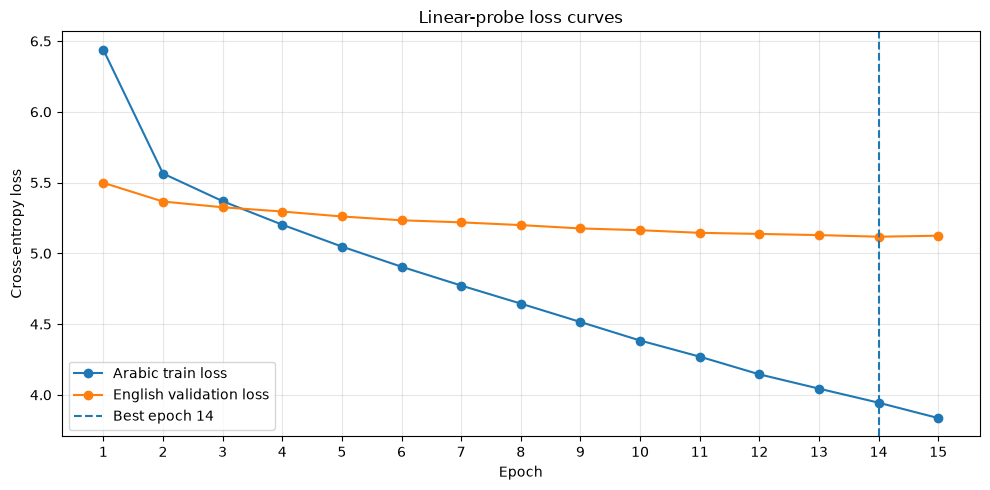

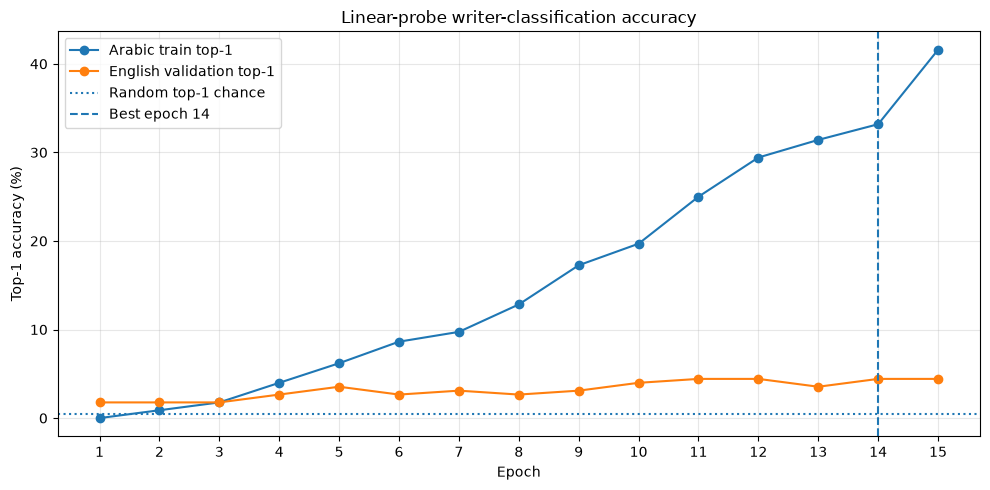

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Arabic train loss",
)

plt.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="English validation loss",
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch {best_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Linear-probe loss curves")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_top1_percent"],
    marker="o",
    label="Arabic train top-1",
)

plt.plot(
    history_df["epoch"],
    history_df["validation_top1_percent"],
    marker="o",
    label="English validation top-1",
)

plt.axhline(
    100 / NUM_CLASSES,
    linestyle=":",
    label="Random top-1 chance",
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch {best_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("Top-1 accuracy (%)")
plt.title("Linear-probe writer-classification accuracy")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
@torch.inference_mode()
def collect_prediction_details(
    model,
    loader,
    label_lookup,
    class_to_writer,
    device,
    condition,
):
    model.eval()

    records = []

    for batch in loader:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        labels = get_writer_labels(
            batch,
            label_lookup,
            device,
        )

        logits = model(images)
        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        sorted_classes = logits.argsort(
            dim=1,
            descending=True,
        )

        predicted_classes = sorted_classes[:, 0]

        true_ranks = (
            sorted_classes
            == labels.unsqueeze(1)
        ).to(torch.long).argmax(dim=1) + 1

        predicted_confidences = probabilities.gather(
            1,
            predicted_classes.unsqueeze(1),
        ).squeeze(1)

        for index in range(images.shape[0]):
            true_class = labels[index].item()
            predicted_class = predicted_classes[index].item()
            true_rank = true_ranks[index].item()

            records.append(
                {
                    "condition": condition,
                    "filename": batch["filename"][index],
                    "page_id": batch["page_id"][index].item(),
                    "language": batch["language"][index],
                    "same_text": batch["same_text"][index].item(),
                    "true_writer_id": class_to_writer[true_class],
                    "predicted_writer_id": class_to_writer[predicted_class],
                    "true_class": true_class,
                    "predicted_class": predicted_class,
                    "true_rank": true_rank,
                    "top1_correct": int(true_rank == 1),
                    "top5_correct": int(true_rank <= 5),
                    "top10_correct": int(true_rank <= 10),
                    "predicted_confidence": predicted_confidences[index].item(),
                }
            )

    return pd.DataFrame(records)


validation_predictions_df = collect_prediction_details(
    model,
    validation_loader,
    writer_label_lookup,
    class_to_writer,
    DEVICE,
    "english_variable_validation",
)

test_predictions_df = collect_prediction_details(
    model,
    test_loader,
    writer_label_lookup,
    class_to_writer,
    DEVICE,
    "english_same_test",
)

print("Validation prediction rows:", len(validation_predictions_df))
print("Test prediction rows:", len(test_predictions_df))
print(
    "Validation columns:",
    validation_predictions_df.columns.tolist(),
)

assert len(validation_predictions_df) == 226
assert len(test_predictions_df) == 226
assert validation_predictions_df["true_rank"].between(1, 226).all()
assert test_predictions_df["true_rank"].between(1, 226).all()

Validation prediction rows: 226
Test prediction rows: 226
Validation columns: ['condition', 'filename', 'page_id', 'language', 'same_text', 'true_writer_id', 'predicted_writer_id', 'true_class', 'predicted_class', 'true_rank', 'top1_correct', 'top5_correct', 'top10_correct', 'predicted_confidence']


In [17]:
def summarize_prediction_ranks(predictions):
    reciprocal_ranks = (
        1.0 / predictions["true_rank"]
    )

    return {
        "samples": len(predictions),
        "top1_accuracy_percent": predictions[
            "top1_correct"
        ].mean() * 100,
        "top5_accuracy_percent": predictions[
            "top5_correct"
        ].mean() * 100,
        "top10_accuracy_percent": predictions[
            "top10_correct"
        ].mean() * 100,
        "mean_reciprocal_rank": reciprocal_ranks.mean(),
        "median_true_rank": predictions[
            "true_rank"
        ].median(),
        "mean_true_rank": predictions[
            "true_rank"
        ].mean(),
        "mean_top1_confidence": predictions[
            "predicted_confidence"
        ].mean(),
    }


prediction_rank_summary = {
    "english_variable_validation": summarize_prediction_ranks(
        validation_predictions_df
    ),
    "english_same_test": summarize_prediction_ranks(
        test_predictions_df
    ),
}

prediction_rank_summary_df = (
    pd.DataFrame(prediction_rank_summary)
    .T
    .reset_index()
    .rename(columns={"index": "condition"})
)

display(
    prediction_rank_summary_df.round(4)
)

assert np.isclose(
    prediction_rank_summary[
        "english_variable_validation"
    ]["top1_accuracy_percent"],
    best_model_metrics[
        "english_variable_validation"
    ]["top1_accuracy"] * 100,
)

assert np.isclose(
    prediction_rank_summary[
        "english_same_test"
    ]["top5_accuracy_percent"],
    best_model_metrics[
        "english_same_test"
    ]["top5_accuracy"] * 100,
)

,condition,samples,top1_accuracy_percent,top5_accuracy_percent,top10_accuracy_percent,mean_reciprocal_rank,median_true_rank,mean_true_rank,mean_top1_confidence
0,english_variable_validation,226.0,4.4248,11.9469,20.7965,0.1007,47.0,67.3230,0.0235
1,english_same_test,226.0,3.5398,14.1593,18.1416,0.0927,53.5,68.5885,0.0285


,rank,english_variable_validation,english_same_test
0,1,4.4248,3.5398
4,5,11.9469,14.1593
9,10,20.7965,18.1416
19,20,30.5310,30.9735
49,50,53.0973,46.9027
99,100,73.8938,73.8938
225,226,100.0000,100.0000


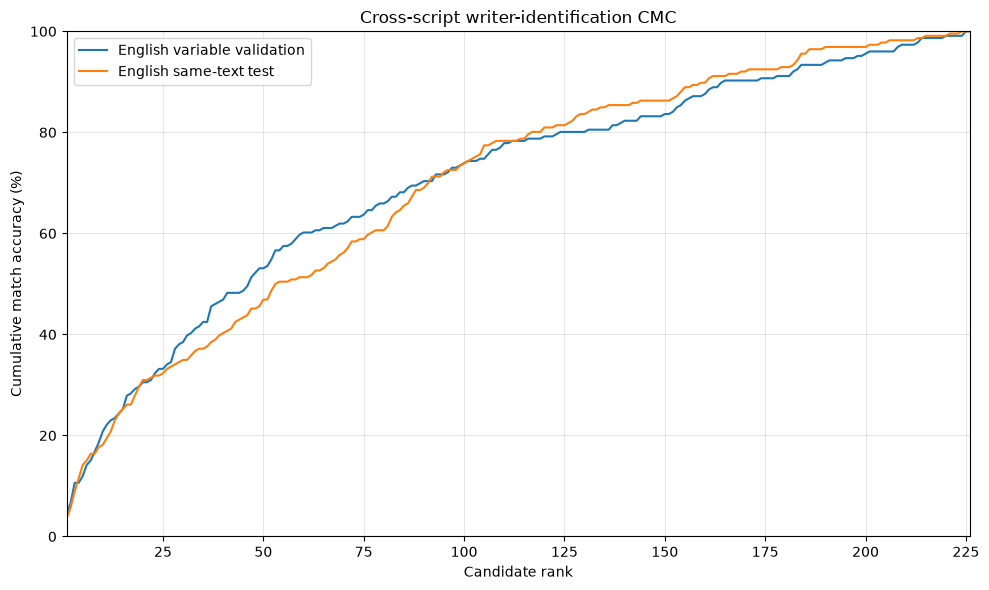

CMC figure path: /home/arijit/Documents/handwriting-cross-script-research/reports/supervised_baseline/resnet18_linear_probe_cmc.png
CMC figure exists: True


In [18]:
ranks = np.arange(
    1,
    NUM_CLASSES + 1,
)


def calculate_cmc(predictions):
    return np.array(
        [
            (
                predictions["true_rank"] <= rank
            ).mean() * 100
            for rank in ranks
        ]
    )


validation_cmc = calculate_cmc(
    validation_predictions_df
)

test_cmc = calculate_cmc(
    test_predictions_df
)

cmc_df = pd.DataFrame(
    {
        "rank": ranks,
        "english_variable_validation": validation_cmc,
        "english_same_test": test_cmc,
    }
)

selected_ranks = [
    1,
    5,
    10,
    20,
    50,
    100,
    226,
]

display(
    cmc_df[
        cmc_df["rank"].isin(selected_ranks)
    ].round(4)
)

cmc_figure_path = (
    REPORT_DIR
    / "resnet18_linear_probe_cmc.png"
)

plt.figure(figsize=(10, 6))

plt.plot(
    cmc_df["rank"],
    cmc_df["english_variable_validation"],
    label="English variable validation",
)

plt.plot(
    cmc_df["rank"],
    cmc_df["english_same_test"],
    label="English same-text test",
)

plt.xlabel("Candidate rank")
plt.ylabel("Cumulative match accuracy (%)")
plt.title("Cross-script writer-identification CMC")
plt.xlim(1, NUM_CLASSES)
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    cmc_figure_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("CMC figure path:", cmc_figure_path)
print("CMC figure exists:", cmc_figure_path.exists())

assert validation_cmc[-1] == 100
assert test_cmc[-1] == 100

In [19]:
history_path = (
    REPORT_DIR
    / "resnet18_linear_probe_history.csv"
)

metrics_path = (
    REPORT_DIR
    / "resnet18_linear_probe_final_metrics.csv"
)

rank_summary_path = (
    REPORT_DIR
    / "resnet18_linear_probe_rank_summary.csv"
)

cmc_path = (
    REPORT_DIR
    / "resnet18_linear_probe_cmc.csv"
)

validation_predictions_path = (
    REPORT_DIR
    / "english_variable_validation_predictions.csv"
)

test_predictions_path = (
    REPORT_DIR
    / "english_same_test_predictions.csv"
)

summary_path = (
    REPORT_DIR
    / "resnet18_linear_probe_summary.json"
)

history_df.to_csv(
    history_path,
    index=False,
)

best_model_metrics_df.to_csv(
    metrics_path,
    index=False,
)

prediction_rank_summary_df.to_csv(
    rank_summary_path,
    index=False,
)

cmc_df.to_csv(
    cmc_path,
    index=False,
)

validation_predictions_df.to_csv(
    validation_predictions_path,
    index=False,
)

test_predictions_df.to_csv(
    test_predictions_path,
    index=False,
)

experiment_summary = {
    "experiment": "supervised_cross_script_writer_classification_linear_probe",
    "dataset": "QUWI",
    "model": "ImageNet-pretrained ResNet-18",
    "training_strategy": "frozen_backbone_linear_probe",
    "training_script": "Arabic",
    "training_pages": [1, 2],
    "validation_script": "English",
    "validation_page": 3,
    "validation_text_condition": "variable",
    "test_script": "English",
    "test_page": 4,
    "test_text_condition": "same",
    "writers": NUM_CLASSES,
    "training_images": len(arabic_train_dataset),
    "validation_images": len(
        english_variable_validation_dataset
    ),
    "test_images": len(
        english_same_test_dataset
    ),
    "target_size": [384, 384],
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "best_epoch": int(best_epoch),
    "random_top1_accuracy_percent": 100 / NUM_CLASSES,
    "random_top5_accuracy_percent": 500 / NUM_CLASSES,
    "final_metrics": {
        condition: {
            key: float(value)
            for key, value in metrics.items()
        }
        for condition, metrics in best_model_metrics.items()
    },
    "rank_metrics": {
        condition: {
            key: float(value)
            for key, value in metrics.items()
        }
        for condition, metrics in prediction_rank_summary.items()
    },
    "checkpoint_path": str(best_checkpoint_path),
}

with summary_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        experiment_summary,
        file,
        indent=2,
    )

saved_report_paths = [
    history_path,
    metrics_path,
    rank_summary_path,
    cmc_path,
    validation_predictions_path,
    test_predictions_path,
    summary_path,
    cmc_figure_path,
]

for path in saved_report_paths:
    print(path.name, ":", path.exists())

assert all(
    path.exists()
    for path in saved_report_paths
)

resnet18_linear_probe_history.csv : True
resnet18_linear_probe_final_metrics.csv : True
resnet18_linear_probe_rank_summary.csv : True
resnet18_linear_probe_cmc.csv : True
english_variable_validation_predictions.csv : True
english_same_test_predictions.csv : True
resnet18_linear_probe_summary.json : True
resnet18_linear_probe_cmc.png : True


In [20]:
def summarize_prediction_distribution(predictions):
    prediction_counts = (
        predictions["predicted_writer_id"]
        .value_counts()
    )

    prediction_probabilities = (
        prediction_counts
        / prediction_counts.sum()
    )

    prediction_entropy = -(
        prediction_probabilities
        * np.log(prediction_probabilities)
    ).sum()

    return {
        "samples": len(predictions),
        "unique_predicted_writers": prediction_counts.size,
        "prediction_coverage_percent": (
            prediction_counts.size
            / NUM_CLASSES
            * 100
        ),
        "maximum_prediction_frequency": int(
            prediction_counts.max()
        ),
        "maximum_prediction_share_percent": (
            prediction_counts.max()
            / len(predictions)
            * 100
        ),
        "prediction_entropy": prediction_entropy,
        "normalized_prediction_entropy": (
            prediction_entropy
            / np.log(NUM_CLASSES)
        ),
        "mean_confidence_percent": (
            predictions[
                "predicted_confidence"
            ].mean()
            * 100
        ),
    }


def get_top_predicted_writers(
    predictions,
    condition,
    top_n=10,
):
    table = (
        predictions["predicted_writer_id"]
        .value_counts()
        .head(top_n)
        .rename_axis("predicted_writer_id")
        .reset_index(name="prediction_count")
    )

    table["condition"] = condition

    table["prediction_share_percent"] = (
        table["prediction_count"]
        / len(predictions)
        * 100
    )

    return table[
        [
            "condition",
            "predicted_writer_id",
            "prediction_count",
            "prediction_share_percent",
        ]
    ]


prediction_distribution_summary = {
    "english_variable_validation": (
        summarize_prediction_distribution(
            validation_predictions_df
        )
    ),
    "english_same_test": (
        summarize_prediction_distribution(
            test_predictions_df
        )
    ),
}

prediction_distribution_summary_df = (
    pd.DataFrame(
        prediction_distribution_summary
    )
    .T
    .reset_index()
    .rename(columns={"index": "condition"})
)

top_predicted_writer_df = pd.concat(
    [
        get_top_predicted_writers(
            validation_predictions_df,
            "english_variable_validation",
        ),
        get_top_predicted_writers(
            test_predictions_df,
            "english_same_test",
        ),
    ],
    ignore_index=True,
)

display(
    prediction_distribution_summary_df.round(4)
)

display(
    top_predicted_writer_df.round(4)
)

,condition,samples,unique_predicted_writers,prediction_coverage_percent,maximum_prediction_frequency,maximum_prediction_share_percent,prediction_entropy,normalized_prediction_entropy,mean_confidence_percent
0,english_variable_validation,226.0,57.0,25.2212,33.0,14.6018,3.4655,0.6393,2.3487
1,english_same_test,226.0,44.0,19.4690,35.0,15.4867,3.0995,0.5718,2.8508


,condition,predicted_writer_id,prediction_count,prediction_share_percent
0,english_variable_validation,268,33,14.6018
1,english_variable_validation,61,20,8.8496
2,english_variable_validation,139,14,6.1947
3,english_variable_validation,247,11,4.8673
4,english_variable_validation,279,10,4.4248
5,english_variable_validation,35,10,4.4248
6,english_variable_validation,246,9,3.9823
7,english_variable_validation,29,9,3.9823
8,english_variable_validation,135,8,3.5398
9,english_variable_validation,125,8,3.5398


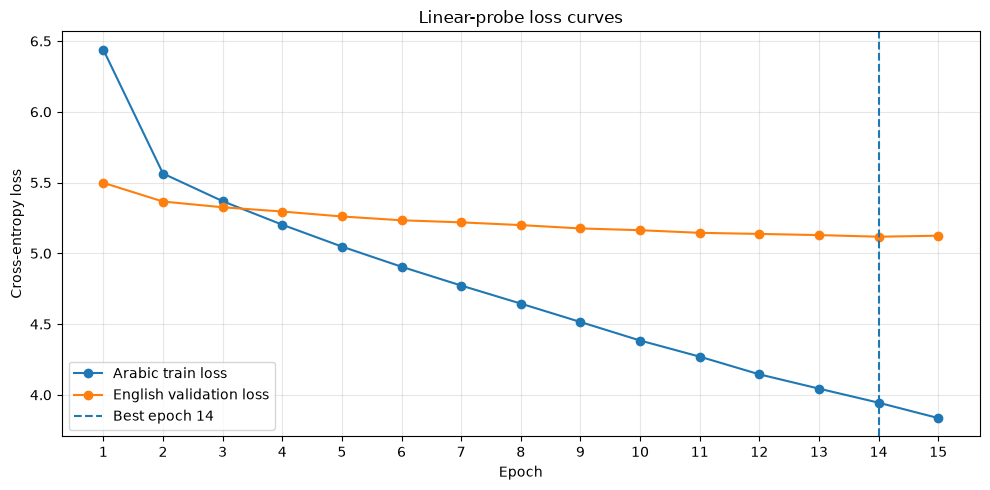

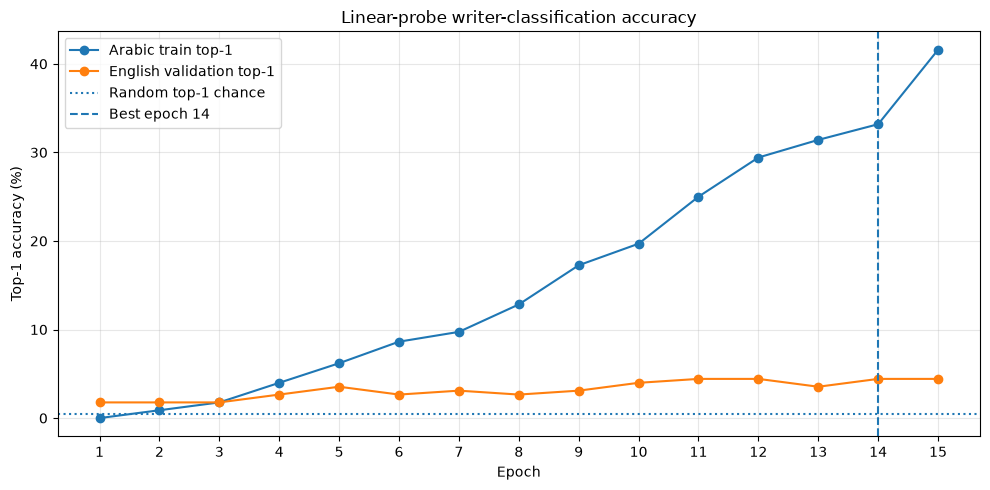

resnet18_linear_probe_prediction_distribution.csv : True
resnet18_linear_probe_top_predicted_writers.csv : True
resnet18_linear_probe_loss_curves.png : True
resnet18_linear_probe_accuracy_curves.png : True
resnet18_linear_probe_summary.json : True


In [21]:
distribution_summary_path = (
    REPORT_DIR
    / "resnet18_linear_probe_prediction_distribution.csv"
)

top_predicted_writer_path = (
    REPORT_DIR
    / "resnet18_linear_probe_top_predicted_writers.csv"
)

loss_figure_path = (
    REPORT_DIR
    / "resnet18_linear_probe_loss_curves.png"
)

accuracy_figure_path = (
    REPORT_DIR
    / "resnet18_linear_probe_accuracy_curves.png"
)

prediction_distribution_summary_df.to_csv(
    distribution_summary_path,
    index=False,
)

top_predicted_writer_df.to_csv(
    top_predicted_writer_path,
    index=False,
)

plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Arabic train loss",
)

plt.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="English validation loss",
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch {best_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Linear-probe loss curves")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    loss_figure_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_top1_percent"],
    marker="o",
    label="Arabic train top-1",
)

plt.plot(
    history_df["epoch"],
    history_df["validation_top1_percent"],
    marker="o",
    label="English validation top-1",
)

plt.axhline(
    100 / NUM_CLASSES,
    linestyle=":",
    label="Random top-1 chance",
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch {best_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("Top-1 accuracy (%)")
plt.title("Linear-probe writer-classification accuracy")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    accuracy_figure_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

experiment_summary[
    "prediction_distribution"
] = {
    condition: {
        key: float(value)
        for key, value in metrics.items()
    }
    for condition, metrics
    in prediction_distribution_summary.items()
}

experiment_summary["report_files"] = [
    path.name
    for path in [
        history_path,
        metrics_path,
        rank_summary_path,
        cmc_path,
        validation_predictions_path,
        test_predictions_path,
        distribution_summary_path,
        top_predicted_writer_path,
        loss_figure_path,
        accuracy_figure_path,
        cmc_figure_path,
    ]
]

with summary_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        experiment_summary,
        file,
        indent=2,
    )

additional_report_paths = [
    distribution_summary_path,
    top_predicted_writer_path,
    loss_figure_path,
    accuracy_figure_path,
    summary_path,
]

for path in additional_report_paths:
    print(path.name, ":", path.exists())

assert all(
    path.exists()
    for path in additional_report_paths
)

In [22]:
validation_prediction_counts = (
    validation_predictions_df["predicted_writer_id"]
    .value_counts()
    .reindex(development_writers, fill_value=0)
    .sort_index()
)

test_prediction_counts = (
    test_predictions_df["predicted_writer_id"]
    .value_counts()
    .reindex(development_writers, fill_value=0)
    .sort_index()
)

prediction_bias_comparison_df = pd.DataFrame(
    {
        "writer_id": development_writers,
        "validation_prediction_count": validation_prediction_counts.values,
        "test_prediction_count": test_prediction_counts.values,
    }
)

prediction_bias_comparison_df[
    "validation_prediction_share_percent"
] = (
    prediction_bias_comparison_df[
        "validation_prediction_count"
    ]
    / len(validation_predictions_df)
    * 100
)

prediction_bias_comparison_df[
    "test_prediction_share_percent"
] = (
    prediction_bias_comparison_df[
        "test_prediction_count"
    ]
    / len(test_predictions_df)
    * 100
)

validation_top10_writers = set(
    validation_prediction_counts
    .sort_values(ascending=False)
    .head(10)
    .index
)

test_top10_writers = set(
    test_prediction_counts
    .sort_values(ascending=False)
    .head(10)
    .index
)

top10_overlap = (
    validation_top10_writers
    & test_top10_writers
)

top10_union = (
    validation_top10_writers
    | test_top10_writers
)

pearson_correlation = (
    prediction_bias_comparison_df[
        [
            "validation_prediction_count",
            "test_prediction_count",
        ]
    ]
    .corr(method="pearson")
    .iloc[0, 1]
)

spearman_correlation = (
    prediction_bias_comparison_df[
        [
            "validation_prediction_count",
            "test_prediction_count",
        ]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

top10_jaccard = (
    len(top10_overlap)
    / len(top10_union)
)

print(
    "Validation top-10 predicted writers:",
    sorted(validation_top10_writers),
)

print(
    "Test top-10 predicted writers:",
    sorted(test_top10_writers),
)

print(
    "Top-10 writer overlap:",
    sorted(top10_overlap),
)

print(
    "Top-10 overlap count:",
    len(top10_overlap),
    "of 10",
)

print(
    "Top-10 Jaccard similarity:",
    round(top10_jaccard, 4),
)

print(
    "Prediction-count Pearson correlation:",
    round(pearson_correlation, 4),
)

print(
    "Prediction-count Spearman correlation:",
    round(spearman_correlation, 4),
)

bias_comparison_path = (
    REPORT_DIR
    / "resnet18_linear_probe_prediction_bias_comparison.csv"
)

prediction_bias_comparison_df.to_csv(
    bias_comparison_path,
    index=False,
)

experiment_summary["cross_condition_prediction_bias"] = {
    "validation_top10_predicted_writers": sorted(
        validation_top10_writers
    ),
    "test_top10_predicted_writers": sorted(
        test_top10_writers
    ),
    "top10_overlap": sorted(top10_overlap),
    "top10_overlap_count": len(top10_overlap),
    "top10_jaccard_similarity": top10_jaccard,
    "prediction_count_pearson_correlation": pearson_correlation,
    "prediction_count_spearman_correlation": spearman_correlation,
}

experiment_summary["report_files"].append(
    bias_comparison_path.name
)

with summary_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        experiment_summary,
        file,
        indent=2,
    )

print(
    "Bias-comparison report exists:",
    bias_comparison_path.exists(),
)

Validation top-10 predicted writers: [29, 35, 61, 125, 135, 139, 246, 247, 268, 279]
Test top-10 predicted writers: [9, 26, 29, 35, 61, 139, 166, 229, 247, 279]
Top-10 writer overlap: [29, 35, 61, 139, 247, 279]
Top-10 overlap count: 6 of 10
Top-10 Jaccard similarity: 0.4286
Prediction-count Pearson correlation: 0.4678
Prediction-count Spearman correlation: 0.5254
Bias-comparison report exists: True


## Experiment conclusion

This notebook established a supervised closed-set cross-script writer-identification baseline using an ImageNet-pretrained ResNet-18.

The model was trained as a linear probe: the ResNet-18 feature extractor remained frozen, while a new 226-class writer-classification layer was optimized using Arabic handwriting from the development writers. Model selection used English variable-text handwriting from the same writers, and English same-text handwriting was reserved for final evaluation.

The best checkpoint was selected at epoch 14. Its principal results were:

- Arabic training top-1 accuracy: 66.81%
- English variable-text validation top-1 accuracy: 4.42%
- English same-text test top-1 accuracy: 3.54%
- English variable-text validation top-5 accuracy: 11.95%
- English same-text test top-5 accuracy: 14.16%
- English variable-text validation top-10 accuracy: 20.80%
- English same-text test top-10 accuracy: 18.14%

The random top-1 and top-5 accuracies for 226 writer classes are 0.44% and 2.21%, respectively. Therefore, the model learned some writer-related information that transferred from Arabic to English. However, the large train–validation gap demonstrates substantial overfitting and limited script invariance.

Prediction-distribution analysis revealed an additional limitation. The model predicted only 57 distinct writer classes on the English variable-text validation set and 44 classes on the English same-text test set. A small group of writer classes received a disproportionate share of the predictions, indicating cross-script prediction bias and partial class collapse.

These findings establish a deliberately simple but informative baseline:

1. Generic ImageNet features contain limited script-independent writer information.
2. A frozen linear probe is insufficient for robust cross-script writer recognition.
3. Script shift is a major source of generalization failure.
4. Later methods should explicitly learn writer-discriminative and script-invariant embeddings.
5. Final research evaluation must use writer-disjoint verification protocols rather than this closed-set classification setting.

Generated outputs are stored under:

- `reports/supervised_baseline/`

The model checkpoint is stored locally under:

- `checkpoints/supervised_baseline/`

The next experimental stage should compare this frozen linear probe with a controlled fine-tuning baseline before moving to metric learning and self-supervised writer verification.